## Parte 0

In [2]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 8.4 MB/s eta 0:05:11
   ---------------------------------------- 0.0/2.6 GB 8.0 MB/s eta 0:05:26
   ---------------------------------------- 0.0/2.6 GB 9.1 MB/s eta 0:04:46
   ---------------------------------------- 0.0/2.6 GB 10.1 MB/s eta 0:04:17
   ---------------------------------------- 0.0/2.6 GB 11.1 MB/s eta 0:03:54
   ---------------------------------------- 0.0/2.6 GB 11.9 MB/s eta 0:03:38
   ---------------------------------------- 0.0/2.6 GB 12.0 MB/s eta 0:03:36
   ---------------------------------------- 0.0/2.6 GB 11.7 MB/s eta 0:03:42
   ---------------------------------------- 0.0/2.6 GB 1

ERROR: Could not install packages due to an OSError: [WinError 206] O nome do arquivo ou a extensão é muito grande: 'C:\\Users\\walle\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\torch-2.14.0+cu126.dist-info\\licenses\\third_party\\flash-attention\\third_party\\aiter\\3rdparty\\composable_kernel'



In [3]:
import numpy as np 
import random
import matplotlib.pyplot as plt
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

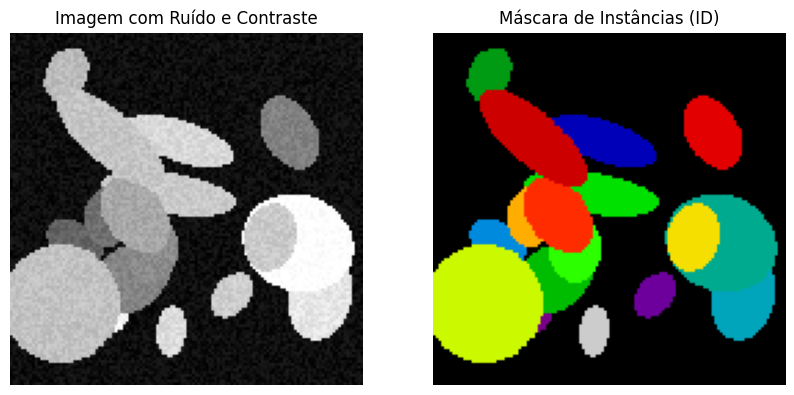

In [8]:
def generateEllipses(img_size):
    # Vamos adicinar um contraste para o fundo da imagem
    bg_intensity = np.random.randint(20,80)
    img = np.full((img_size, img_size), bg_intensity, dtype=np.uint8)

    # Evitar overflow
    mask = np.zeros((img_size, img_size), dtype=np.int32)

    num_ellipses = np.random.randint(15,21)

    # Para cada elipse, define o formato, a posição e a intensidade
    for i in range(1, num_ellipses+1):
        center = (int(np.random.randint(15, img_size-15)), int(np.random.randint(15, img_size-15)))
        axes = (int(np.random.randint(5,25)), int(np.random.randint(5,25)))
        angle = int(np.random.randint(0,180))
        intensity = int(np.random.randint(100,255))

        cv2.ellipse(img, center, axes, angle, 0, 360, intensity, -1)
        cv2.ellipse(mask, center, axes, angle, 0, 360, i, -1)

    std_dev = np.random.uniform(5.0, 30.0)
    noise = np.random.uniform(0, std_dev, (img_size, img_size))

    noisy_img = np.clip(img + noise, 0, 255)

    return noisy_img, mask

img, mask = generateEllipses(128)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem com Ruído e Contraste")
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Máscara de Instâncias (ID)")
axes[1].axis('off')
plt.show()

In [ ]:
class EllipsesDataset(Dataset):
  def __init__(self, num_samples) -> None:
     self.num_samples = num_samples
    
  def __len__(self):
    return self.num_samples
  
  def __getitem__(self, index):
    img, mask = generateEllipses(128)
    tensor_img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    tensor_mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    return tensor_img, tensor_mask

ellip_data = EllipsesDataset(1000)
ellip_loader = DataLoader(ellip_data, batch_size=16)

In [ ]:
# Para treinar com as elipses criadas acima usaremos a U-Net
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels) -> None:
     super(DoubleConv, self).__init__()
     self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
     )

  def forward(self,x):
    return self.conv(x)

class UNet(nn.Module):
  def __init__(self, in_channels, out_channels) -> None:
     super(UNet, self).__init__()
     # Encoder
     self.conv1 = DoubleConv(in_channels, 64)
     self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
     self.conv2 = DoubleConv(64,128)
     self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

     # Bottleneck
     self.bottleneck = DoubleConv(128,256)

     # Decoder
     self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
     self.dec1 = DoubleConv(256,128)
     self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
     self.dec2 = DoubleConv(128,64)

     # Output
     self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

  def forward(self, x):
    # Passa pelo primeiro bloco e salva
    skip1 = self.enc1(x)
    x = self.pool1(skip1)
    skip2 = self.enc2(x)
    x = self.pool2(skip2)

    x = self.bottleneck(x)
    x = self.up1(x)

    x = torch.cat((skip2, x), dim=1)
    x = self.dec1(x)
    x = self.up2(x)
    x = torch.cat((skip1, x), dim=1)

    return self.final_conv(x)